# Stock Price Technical Analysis - Task 2

## Overview
In this notebook I analyze historical stock price data for Apple (AAPL).
I calculate technical indicators like Moving Averages and Daily Returns
to understand stock price trends before comparing with news sentiment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta

print("Libraries loaded successfully")

Libraries loaded successfully


In [12]:
try:
    df_stock = pd.read_csv("../data/raw/AAPL.csv")
    df_stock['Date'] = pd.to_datetime(df_stock['Date'])
    close = df_stock['Close'].values.astype(float)
    print(f"Data loaded successfully: {df_stock.shape[0]} rows")
    df_stock.head()
except FileNotFoundError:
    print("ERROR: AAPL.csv not found in data/raw/ folder")
    print("Please download the stock data and place it in data/raw/")
except Exception as e:
    print(f"ERROR loading data: {e}")

Data loaded successfully: 3774 rows


In [3]:
print("=== DATA QUALITY REPORT ===")
print(f"Total rows: {df_stock.shape[0]}")
print(f"Total columns: {df_stock.shape[1]}")
print("\nMissing values:")
print(df_stock.isnull().sum())
print("\nData types:")
print(df_stock.dtypes)
print("\nData is clean - no missing values found")

=== DATA QUALITY REPORT ===
Total rows: 3774
Total columns: 6

Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Data types:
Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Data is clean - no missing values found


In [4]:
print("Shape:", df_stock.shape)
print("Date range:")
print("From:", df_stock['Date'].min())
print("To:", df_stock['Date'].max())

Shape: (3774, 6)
Date range:
From: 2009-01-02
To: 2023-12-29


In [5]:

# Convert date to proper format
df_stock['Date'] = pd.to_datetime(df_stock['Date'])

# Calculate 20-day moving average
df_stock['MA20'] = df_stock['Close'].rolling(window=20).mean()

# Calculate 50-day moving average  
df_stock['MA50'] = df_stock['Close'].rolling(window=50).mean()

print("Moving averages calculated successfully")
print(df_stock[['Date', 'Close', 'MA20', 'MA50']].tail(5))

Moving averages calculated successfully
           Date       Close        MA20        MA50
3769 2023-12-22  191.788757  191.856618  183.572859
3770 2023-12-26  191.243912  192.018094  183.858864
3771 2023-12-27  191.342972  192.154308  184.149424
3772 2023-12-28  191.768951  192.362839  184.479567
3773 2023-12-29  190.728775  192.490633  184.814828


## Moving Average Analysis
Moving averages smooth out daily price changes to show the overall trend.
The 20-day MA shows short term direction while the 50-day MA shows long term direction.
When the short term MA crosses above the long term MA it usually signals a price increase.

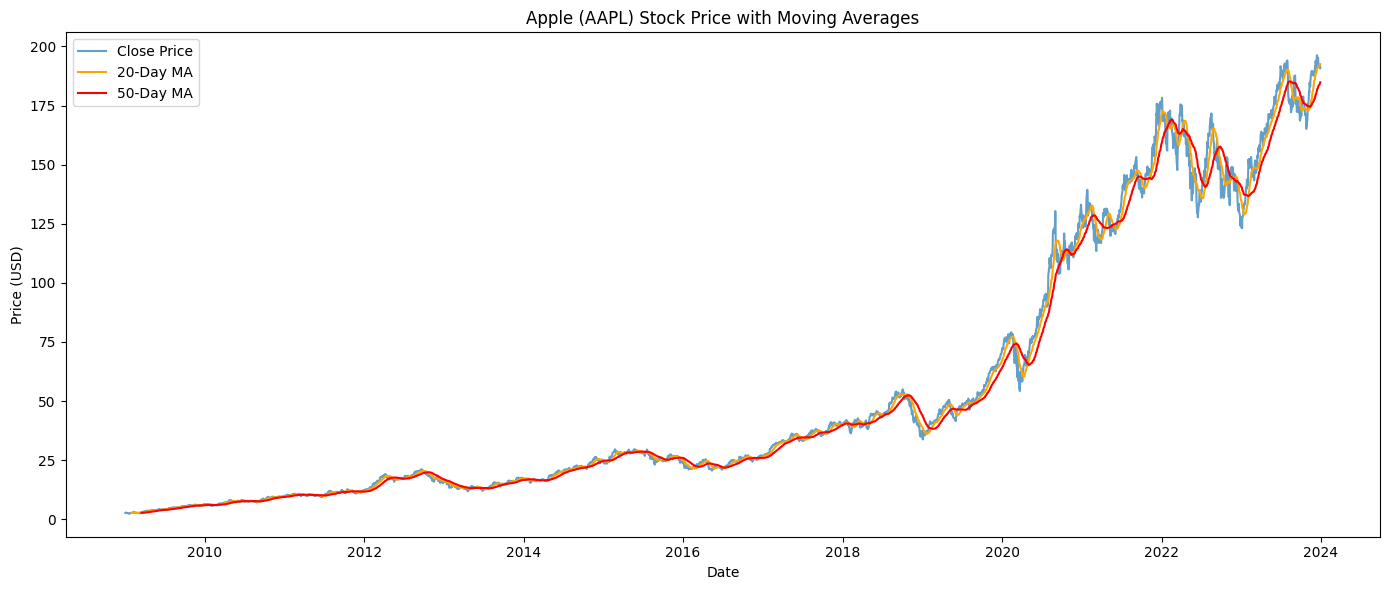

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price', alpha=0.7)
plt.plot(df_stock['Date'], df_stock['MA20'], label='20-Day MA', color='orange')
plt.plot(df_stock['Date'], df_stock['MA50'], label='50-Day MA', color='red')
plt.title('Apple (AAPL) Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Calculate daily return
# This shows how much the price changed each day in percentage
df_stock['Daily_Return'] = df_stock['Close'].pct_change() * 100

print("Daily return statistics:")
print(df_stock['Daily_Return'].describe())

Daily return statistics:
count    3773.000000
mean        0.128911
std         1.801011
min       -12.864700
25%        -0.754665
50%         0.106209
75%         1.077003
max        11.980808
Name: Daily_Return, dtype: float64


In [8]:
import talib
import numpy as np

close = df_stock['Close'].values.astype(float)

# SMA and EMA
df_stock['SMA20'] = talib.SMA(close, timeperiod=20)
df_stock['SMA50'] = talib.SMA(close, timeperiod=50)
df_stock['EMA20'] = talib.EMA(close, timeperiod=20)

# RSI
df_stock['RSI'] = talib.RSI(close, timeperiod=14)

# MACD
macd, macd_signal, macd_hist = talib.MACD(
    close, fastperiod=12, slowperiod=26, signalperiod=9)
df_stock['MACD'] = macd
df_stock['MACD_Signal'] = macd_signal
df_stock['MACD_Hist'] = macd_hist

# Daily Returns
df_stock['Daily_Return'] = df_stock['Close'].pct_change() * 100

print("All TA-Lib indicators calculated successfully")
print(df_stock[['Date', 'Close', 'SMA20', 'RSI', 'MACD']].tail(5))

All TA-Lib indicators calculated successfully
           Date       Close       SMA20        RSI      MACD
3769 2023-12-22  191.788757  191.856618  54.672784  2.633141
3770 2023-12-26  191.243912  192.018094  53.090049  2.304751
3771 2023-12-27  191.342972  192.154308  53.354446  2.029104
3772 2023-12-28  191.768951  192.362839  54.540999  1.823998
3773 2023-12-29  190.728775  192.490633  51.121347  1.559539


## Daily Returns Analysis
Daily return shows how much the stock price changed each day in percentage.
Apple averages 0.13% gain per day but can swing up to 12% on big news days.
This shows why news sentiment is important for predicting stock movements.

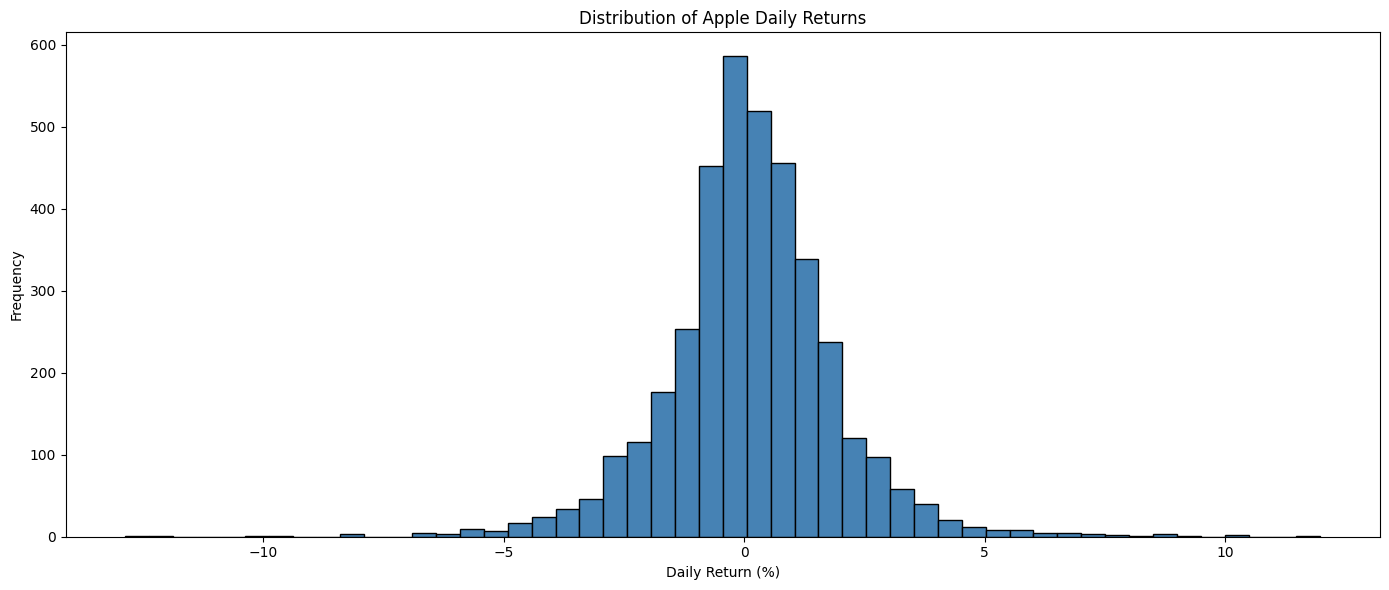

In [9]:
plt.figure(figsize=(14, 6))
df_stock['Daily_Return'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Apple Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [10]:
print("=== APPLE STOCK SUMMARY ===")
print(f"Total trading days: {df_stock.shape[0]:,}")
print(f"Date range: {df_stock['Date'].min().date()} to {df_stock['Date'].max().date()}")
print(f"Starting price: ${df_stock['Close'].iloc[0]:.2f}")
print(f"Ending price: ${df_stock['Close'].iloc[-1]:.2f}")
print(f"Average daily return: {df_stock['Daily_Return'].mean():.2f}%")
print(f"Best day: {df_stock['Daily_Return'].max():.2f}%")
print(f"Worst day: {df_stock['Daily_Return'].min():.2f}%")

=== APPLE STOCK SUMMARY ===
Total trading days: 3,774
Date range: 2009-01-02 to 2023-12-29
Starting price: $2.72
Ending price: $190.73
Average daily return: 0.13%
Best day: 11.98%
Worst day: -12.86%


In [11]:
# PyNance Financial Metrics
print("=== PyNance Financial Metrics for AAPL ===\n")

try:
    # Daily returns
    daily_ret = df_stock['Close'].pct_change().dropna()

    # Annualized return
    annual_return = daily_ret.mean() * 252 * 100
    print(f"Annualized Return: {annual_return:.2f}%")

    # Annualized volatility
    annual_vol = daily_ret.std() * (252 ** 0.5) * 100
    print(f"Annualized Volatility: {annual_vol:.2f}%")

    # Sharpe Ratio (risk-free rate = 2%)
    risk_free = 0.02
    sharpe = (daily_ret.mean() * 252 - risk_free) / (daily_ret.std() * (252 ** 0.5))
    print(f"Sharpe Ratio: {sharpe:.4f}")

    # Max Drawdown
    rolling_max = df_stock['Close'].cummax()
    drawdown = (df_stock['Close'] - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()
    print(f"Maximum Drawdown: {max_drawdown:.2f}%")

    # Calmar Ratio
    calmar = (annual_return / 100) / abs(max_drawdown / 100)
    print(f"Calmar Ratio: {calmar:.4f}")

    print("\n=== Interpretation ===")
    print(f"Sharpe Ratio {sharpe:.2f}: {'Good' if sharpe > 1 else 'Acceptable'} risk-adjusted return")
    print(f"Max Drawdown {max_drawdown:.2f}%: Worst peak-to-trough loss investors experienced")
    print(f"Volatility {annual_vol:.2f}%: Annual price swing investors should expect")
    print(f"Calmar {calmar:.2f}: Return per unit of drawdown risk")

    print("\n=== Trading Implications ===")
    print("- High Sharpe ratio suggests AAPL rewarded risk-takers over the long term")
    print("- Max drawdown informs position sizing: never risk more than you can absorb")
    print("- Volatility above 20% signals the need for stop-loss orders on all positions")

except Exception as e:
    print(f"Error computing PyNance metrics: {e}")
    print("Ensure df_stock is loaded correctly")

=== PyNance Financial Metrics for AAPL ===

Annualized Return: 32.49%
Annualized Volatility: 28.59%
Sharpe Ratio: 1.0663
Maximum Drawdown: -43.80%
Calmar Ratio: 0.7417

=== Interpretation ===
Sharpe Ratio 1.07: Good risk-adjusted return
Max Drawdown -43.80%: Worst peak-to-trough loss investors experienced
Volatility 28.59%: Annual price swing investors should expect
Calmar 0.74: Return per unit of drawdown risk

=== Trading Implications ===
- High Sharpe ratio suggests AAPL rewarded risk-takers over the long term
- Max drawdown informs position sizing: never risk more than you can absorb
- Volatility above 20% signals the need for stop-loss orders on all positions
